In [4]:
import pandas as pd
import numpy as np


In [5]:
df = pd.read_csv('/content/Churn_Modelling.csv')

In [6]:
df.shape

(10000, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [8]:
df.sample(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
923,924,15601026,Gallagher,572,Germany,Female,19,1,138657.08,1,1,1,16161.82,0
2377,2378,15637650,Williams,549,France,Male,50,9,94748.76,2,0,1,13608.18,0
4133,4134,15667602,Cheng,704,Spain,Male,33,3,0.00,2,1,0,73018.74,0
1052,1053,15623471,Marcelo,607,Germany,Male,38,3,98205.77,1,1,0,176318.27,0
3427,3428,15715079,Bold,465,France,Male,41,9,117221.15,1,1,0,168280.95,0
5844,5845,15711921,Scott,695,France,Male,29,5,0.00,2,1,1,6770.44,0
7496,7497,15608804,Allan,824,Germany,Male,49,8,133231.48,1,1,1,67885.37,0
1387,1388,15674526,Byrne,725,France,Male,66,4,86459.80,1,1,1,141476.56,0
9696,9697,15638788,Mack,550,France,Male,32,8,97514.07,1,1,1,199138.84,0
42,43,15687946,Osborne,556,France,Female,61,2,117419.35,1,1,1,94153.83,0


In [9]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [10]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [11]:
data = pd.get_dummies(df,columns=['Geography','Gender'],dtype=int,drop_first=True)

In [12]:
df.sample(10)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9191,572,France,Male,30,6,117696.67,1,1,0,100843.82,0
1541,654,Germany,Male,37,5,112146.12,1,1,0,75927.35,0
730,591,France,Male,24,6,147360.00,1,1,1,25310.82,0
4122,577,France,Male,60,10,125389.70,2,1,1,178616.73,0
9541,603,France,Male,38,8,59360.77,1,1,1,191457.06,0
3131,648,Germany,Female,39,3,126935.98,2,0,1,57995.74,0
6437,623,France,Female,37,4,140211.88,1,1,1,93832.33,0
4979,616,Germany,Female,45,4,122793.96,1,1,1,62002.04,0
6230,592,France,Male,71,4,0.00,2,0,1,17013.54,0
179,754,Germany,Female,55,3,161608.81,1,1,0,8080.85,1


In [13]:
X = df.drop(columns='Exited')
y = df['Exited']

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
transformer = ColumnTransformer(
    [
        ('encoder',OneHotEncoder(drop='first',sparse_output=False),['Geography','Gender']),
        ('scale',StandardScaler(),['CreditScore','Age','Balance','EstimatedSalary','Tenure','NumOfProducts'])
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

In [17]:
X_train = transformer.fit_transform(X_train)

In [18]:
X_test = transformer.transform(X_test)

In [19]:
import tensorflow

In [20]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [21]:
model = Sequential()
model.add(Dense(10,activation='relu',input_dim=11))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [24]:
history = model.fit(X_train,y_train,epochs=60,validation_split=0.2,batch_size=50)

Epoch 1/60
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7769 - loss: 0.5504 - val_accuracy: 0.7987 - val_loss: 0.4753
Epoch 2/60
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7934 - loss: 0.4706 - val_accuracy: 0.8000 - val_loss: 0.4471
Epoch 3/60
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8009 - loss: 0.4483 - val_accuracy: 0.8188 - val_loss: 0.4293
Epoch 4/60
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8103 - loss: 0.4324 - val_accuracy: 0.8225 - val_loss: 0.4160
Epoch 5/60
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8173 - loss: 0.4181 - val_accuracy: 0.8288 - val_loss: 0.4065
Epoch 6/60
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8217 - loss: 0.4056 - val_accuracy: 0.8319 - val_loss: 0.3953
Epoch 7/60
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8300 - loss: 0.3925 - val_accuracy: 0.8406 - val_loss: 0.3851
Epoch 8/60
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8403 - loss: 0.3799 - val_accuracy: 0.

In [25]:
model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.03151455],
       [0.02240643],
       [0.10232139],
       ...,
       [0.7412557 ],
       [0.1029981 ],
       [0.33563575]], dtype=float32)

In [26]:
y_pred=np.where(model.predict(X_test)<0.5,0,1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [27]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.861

In [28]:
import matplotlib.pyplot as plt

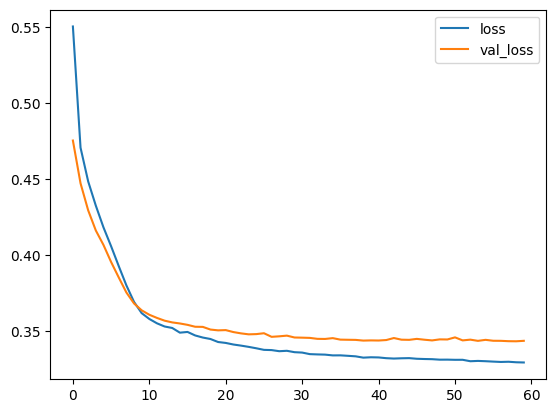

In [29]:
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.legend()



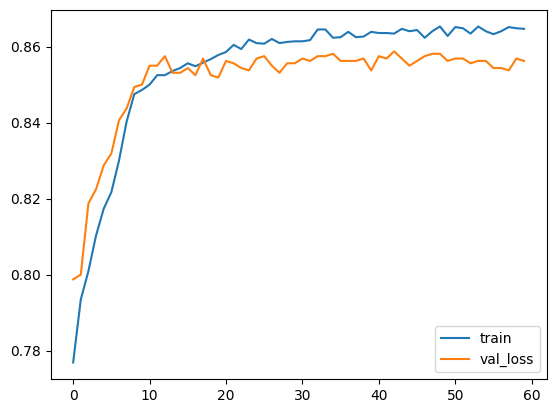

In [30]:
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='val_loss')
plt.legend()



# Hyperparameter Tuning

In [31]:
X_train


,Geography_Germany,Geography_Spain,Gender_Male,CreditScore,Age,Balance,EstimatedSalary,Tenure,NumOfProducts,HasCrCard,IsActiveMember
9254,0.0,0.0,1.0,0.356500,-0.655786,-1.218471,1.367670,0.345680,0.808436,1,1
1561,1.0,0.0,1.0,-0.203898,0.294938,0.696838,1.661254,-0.348369,0.808436,1,1
1670,0.0,1.0,1.0,-0.961472,-1.416365,0.618629,-0.252807,-0.695393,-0.916688,1,0
6087,0.0,0.0,0.0,-0.940717,-1.131148,0.953212,0.915393,1.386753,-0.916688,1,0
6669,0.0,0.0,1.0,-1.397337,1.625953,1.057449,-1.059600,1.386753,-0.916688,0,0
...,...,...,...,...,...,...,...,...,...,...,...
5734,0.0,0.0,1.0,1.207474,1.435808,-0.102301,-0.539860,1.039728,-0.916688,1,1
5191,0.0,0.0,0.0,0.314989,1.816097,-1.218471,-1.733882,-1.389442,-0.916688,1,1
5390,0.0,0.0,0.0,0.865009,-0.085351,-1.218471,-0.142765,-1.389442,2.533560,0,0
860,0.0,0.0,1.0,0.159323,0.390011,1.827259,-0.050826,1.039728,-0.916688,1,0


In [34]:
X_train.shape

(8000, 11)

In [38]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.3 MB/s eta 0:00:00


In [40]:
from tensorflow import keras
from keras.layers import Dense, Dropout
from keras.models import Sequential

import keras_tuner as kt

In [35]:
# adding multiple optimizers

def model_building(hp):

  model = Sequential()

  model.add(Dense(10,activation='relu',input_dim=11))
  model.add(Dense(1,activation='sigmoid'))

  optimizer = hp.Choice('optimizer',['RMSprop','SGD','Adam','Adadelta','Adagrad'])

  model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['accuracy'])

  return model


In [43]:
tuner = kt.RandomSearch(model_building,objective='val_loss',max_trials=5)

In [44]:
tuner.search(X_train,y_train,epochs=5,validation_data = (X_test,y_test))

Trial 5 Complete [00h 00m 05s]
val_loss: 0.4198286533355713

Best val_loss So Far: 0.3746168911457062
Total elapsed time: 00h 00m 35s


In [47]:
model = tuner.get_best_models()[0]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [48]:
history = model.fit(X_train,y_train,epochs=100,initial_epoch=6,validation_data=(X_test,y_test))

Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8425 - loss: 0.3753 - val_accuracy: 0.8405 - val_loss: 0.3661
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8474 - loss: 0.3677 - val_accuracy: 0.8460 - val_loss: 0.3606
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8525 - loss: 0.3625 - val_accuracy: 0.8485 - val_loss: 0.3576
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8525 - loss: 0.3588 - val_accuracy: 0.8520 - val_loss: 0.3541
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8535 - loss: 0.3553 - val_accuracy: 0.8535 - val_loss: 0.3517
Epoch 12/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8536 - loss: 0.3533 - val_accuracy: 0.8555 - val_loss: 0.3500
Epoch 13/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8553 - loss: 0.3511 - val_accuracy: 0.8555 - val_loss: 0.3489
Epoch 14/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8546 - loss: 0.3496 - val

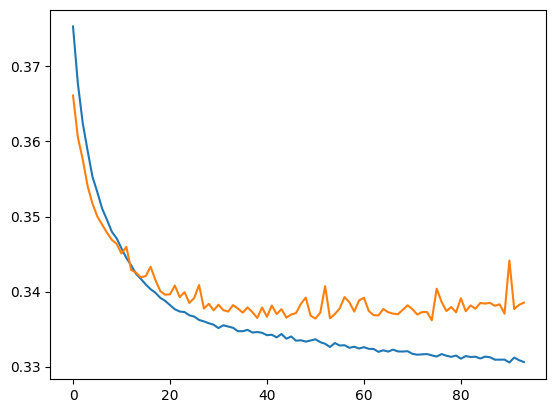

In [49]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [78]:
def model_building(hp):

  model = Sequential()


  activation = ['relu','tanh','elu','selu']
  dropout = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]


  counter = 0
  # for layers
  for i in range(hp.Choice('layer',[2,3,4,5,6,7,8,9,10])):
    if counter == 0:
      model.add(
          Dense(
              units=hp.Int('unit'+str(i),min_value=8,max_value=128,step=8),                   #for neurons
              activation = hp.Choice('activation' + str(i),values = activation),       # for activation
              input_dim = 11
          )
      )
      model.add(Dropout(hp.Choice('dropout'+str(i),values = dropout)))
    else:
      model.add(
          Dense(
              units=hp.Int('unit'+str(i),min_value=8,max_value=128,step=8),
              activation = hp.Choice('activation' + str(i),values = activation)
          )
      )
      model.add(Dropout(hp.Choice('dropout'+str(i),values = dropout)))
      counter +=1

  model.add(Dense(1,activation='sigmoid'))

  model.compile(
      optimizer=hp.Choice('optimizer',values = ['Adam','Adagrad','RMSprop','Adadelta','SGD','Nadam']),
      loss='binary_crossentropy',metrics=['accuracy']
  )

  return model



In [79]:
tuner = kt.BayesianOptimization(model_building,objective='val_loss',overwrite=True,max_trials=100)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [80]:
tuner.search(X_train,y_train,epochs = 10, validation_data=(X_test,y_test))

Trial 100 Complete [00h 00m 18s]
val_loss: 0.3419385850429535

Best val_loss So Far: 0.34008145332336426
Total elapsed time: 00h 28m 18s


In [81]:
model = tuner.get_best_models()[0]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 27 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [82]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 40)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 80)             │         3,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 96)             │         3,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 40)             │         3,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,441 (52.50 KB)

 Trainable params: 13,441 (52.50 KB)

 Non-trainable params: 0 (0.00 B)

In [83]:
callback = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.5,
    patience=0,
    verbose=0,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
    start_from_epoch=30,
)


In [84]:
history = model.fit(X_train,y_train,epochs = 200,initial_epoch=11,validation_data=(X_test,y_test),callbacks=[callback])

Epoch 12/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8485 - loss: 0.3711 - val_accuracy: 0.8555 - val_loss: 0.3382
Epoch 13/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8500 - loss: 0.3709 - val_accuracy: 0.8605 - val_loss: 0.3443
Epoch 14/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8494 - loss: 0.3686 - val_accuracy: 0.8640 - val_loss: 0.3402
Epoch 15/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8510 - loss: 0.3648 - val_accuracy: 0.8605 - val_loss: 0.3331
Epoch 16/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8504 - loss: 0.3676 - val_accuracy: 0.8640 - val_loss: 0.3335
Epoch 17/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8515 - loss: 0.3653 - val_accuracy: 0.8640 - val_loss: 0.3349
Epoch 18/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8501 - loss: 0.3617 - val_accuracy: 0.8555 - val_loss: 0.3386
Epoch 19/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8553 - loss: 0.3610 - 

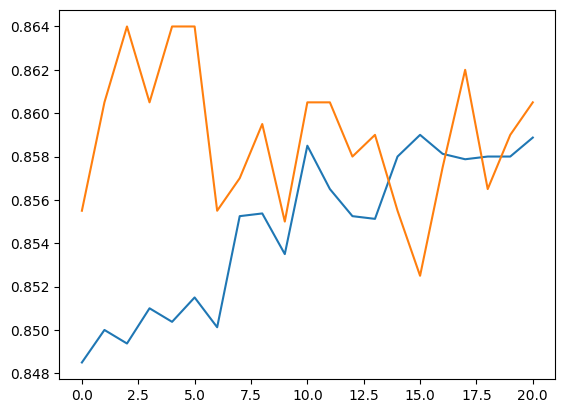

In [85]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])